<a href="https://colab.research.google.com/github/ghostshahinul/quantum_error_correction/blob/main/Fibonacci_Decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Nixon–Brown Fibonacci-Code Decoder — an interactive walkthrough

This notebook is a **fully explicit, self-contained** Python port of the C++
Fibonacci-code decoder (`main.cpp`, `Decoder.cpp`, `BasicFunctions.cpp`,
`CreateEdgeWeightLookup.cpp`, `ImportN/D.cpp`). Every stage of the pipeline is
defined in a cell below, with the physics explained alongside it, and an
interactive animation of the residual syndrome shrinking under correction.

## The decoding pipeline

| Stage | Function here | C++ origin |
|---|---|---|
| Geometry (torus) | `positive_modulo`, `*_vertex`, `vertex_x/y_position` | `BasicFunctions.cpp` |
| Error | i.i.d. bit-flip (or preset) | `TestCode` |
| Syndrome | `star_measurement` | `StarMeasurement` |
| Fractal symmetry | `create_symmetry` (rule-150 CA) | `CreateSymmetry` |
| Symmetry graph | `create_adjacency_list_symmetry` | `CreateAdjacencyListSymmetryLocations` |
| Edge weights | `build_edge_weight_matrix` | `create_edge_weight_lookup_local` |
| Matching | `minimum_weight_matching_symmetry_index` | `…UsingSymmetryIndex` + Blossom |
| Correction | `test_code` (Flexible strategy) | `TestCode` |
| Success | exact `prediction == error` | `TestCode` |

## One honest caveat (read this)

The C++ `main()` reads the matching weights from the **692 KB precomputed
blobs** `ImportN.cpp` / `ImportD.cpp` (only for `L ∈ {8,16,32,64}`). Those
tables are opaque embedded data and are **not generated anywhere in the repo**,
so they cannot be reproduced "explicitly". Instead we compute the two
ingredients directly from the Fibonacci-symmetry graph that the C++ *does*
define:

$$ d_{ij} = \text{BFS shortest-path length}, \qquad
   N_{ij} = \#\{\text{shortest paths}\} \;(\text{geodesic degeneracy}) $$

and form the **identical C++ weight formula**

$$ c = \log\frac{p}{1-p}, \qquad
   w_{ij} = \mathrm{round}\!\big(1000\,(-\log N_{ij} - d_{ij}\,c)\big). $$

- `WEIGHT_MODE = "distance"` → `w = d` (this is *exactly* the explicit
  `MinimumWeightMatchingDecoderFibbonacci` in `Decoder.cpp`; provably faithful).
- `WEIGHT_MODE = "degeneracy"` → the `round(1000·(…))` formula (reproduces
  `main()`'s formula; the geodesic reading of `N` is a reconstruction).


## 0. Imports & configuration

The only non-stdlib dependency is **networkx** (for the Blossom matching, the
analogue of the Blossom-V "black box"). If it is missing, an exact pure-Python
DP fallback is used for small defect counts. `matplotlib` / `ipywidgets` are
used for the visualizations.

In [6]:
import math
import random
from collections import deque

try:
    import networkx as _nx
    _HAVE_NX = True
except Exception:
    _HAVE_NX = False

print("networkx available:", _HAVE_NX)

# "degeneracy" reproduces main(); "distance" is the provably-faithful d-only weight
WEIGHT_MODE = "degeneracy"


networkx available: True


## 1. Lattice geometry (the torus)

The lattice is `L` wide and `H = L/2` tall, with **periodic boundary
conditions** (a torus). Every face carries one qubit **and** one star
stabilizer. A face is addressed by a single integer `v ∈ [0, L·H)`:

$$ x = v \bmod L \quad(\text{column}), \qquad y = \lfloor v/L \rfloor \quad(\text{row, 0 at top}). $$

The neighbour functions wrap around the edges.

In [7]:
def positive_modulo(num, modulo):
    x = num % modulo
    return x + modulo if x < 0 else x

def vertex_x_position(vertex, L):
    return positive_modulo(vertex, L)

def vertex_y_position(vertex, L):
    return vertex // L

def east_vertex(vertex, L):
    if positive_modulo(vertex, L) == L - 1:
        return vertex - (L - 1)
    return vertex + 1

def west_vertex(vertex, L):
    if vertex % L == 0:
        return vertex + (L - 1)
    return vertex - 1

def north_vertex(vertex, L, H):
    if (vertex - L) < 0:
        return vertex - L + L * H
    return vertex - L

def south_vertex(vertex, L, H):
    return positive_modulo(vertex + L, L * H)

def south_row(row, H):
    return positive_modulo(row + 1, H)

def switchbool(b):
    return 1 - b


## 2–3. Error & syndrome extraction

**Error:** an independent bit-flip on each qubit with probability `p`.

**Syndrome:** the Fibonacci-code star stabilizer at face `v` is the parity of
the four qubits at **North, East, West, and the face itself**:

$$ s(v) = q_{N(v)} \oplus q_{E(v)} \oplus q_{W(v)} \oplus q_{v}. $$

Equivalently, **flipping qubit `q` toggles the four stabilizers
`{q, S(q), W(q), E(q)}`** — the fact the corrector uses.

In [8]:
def star_measurement(qubits, vertex, L, H):
    nv = north_vertex(vertex, L, H)
    ev = east_vertex(vertex, L)
    wv = west_vertex(vertex, L)
    return qubits[nv] ^ qubits[ev] ^ qubits[wv] ^ qubits[vertex]

def measure_all_stabilizers(qubits, L, H):
    return [star_measurement(qubits, j, L, H) for j in range(L * H)]


## 4. The fractal (Fibonacci) symmetry

This is the heart of the code. Start with a single `1` in column 0 of the top
row, then grow each subsequent row with the **elementary cellular automaton
"rule 150"** (sum of the three cells above, mod 2), with periodic boundaries:

$$ \text{next}[j] = \big(\text{above}[j{-}1] + \text{above}[j] + \text{above}[j{+}1]\big) \bmod 2. $$

The **symmetry** is the set of faces where the CA is `1`. Its defining property:
for *any* valid syndrome, the number of lit stabilizers lying on (any translate
of) the symmetry is **even** — which is exactly what guarantees a perfect
matching exists at every step.

In [9]:
def create_symmetry(L, H, top_row):
    if len(top_row) != L:
        print("Top row length is incorrect")
    all_rows = [list(top_row)]
    for i in range(H - 1):
        row_above = all_rows[i]
        next_row = [(row_above[j] + row_above[(j + 1) % L]
                     + row_above[positive_modulo(j - 1, L)]) % 2
                    for j in range(L)]
        all_rows.append(next_row)
    symmetry = [i * L + j for i in range(H) for j in range(L) if all_rows[i][j]]
    # sanity check: bottom row must induce the top row under the CA
    e = positive_modulo(all_rows[H - 1][0] + all_rows[H - 1][positive_modulo(-1, L)]
                        + all_rows[H - 1][1], 2)
    if e != top_row[0]:
        print("Bottom row does not induce top row")
    return symmetry

def create_symmetry_reverse(symmetry, LxH):
    rev = [-1] * LxH
    for i, v in enumerate(symmetry):
        rev[v] = i
    return rev

def find_corresponding_indices(symmetry, stabilizers, N):
    on_sym = [0] * N
    for v in symmetry:
        on_sym[v] = 1
    return [i for i in range(N) if on_sym[i] and stabilizers[i]]

def index_defects_by_symmetry_num(symmetry_reverse, defect_lattice_locations):
    return [symmetry_reverse[d] for d in defect_lattice_locations]


### Visualize the symmetry (smallest lattice, `L=8`, `H=4`)

In [10]:
L, H = 8, 4
top_row = [0] * L; top_row[0] = 1
symmetry = create_symmetry(L, H, top_row)
print("symmetry has", len(symmetry), "sites:", symmetry, "\n")
for y in range(H):
    print("   " + " ".join("#" if (y*L+x) in set(symmetry) else "." for x in range(L)))


symmetry has 12 sites: [0, 8, 9, 15, 16, 18, 22, 24, 26, 27, 29, 30] 

   # . . . . . . .
   # # . . . . . #
   # . # . . . # .
   # . # # . # # .


## 5. Symmetry adjacency graph

Two symmetry sites are **one step apart** if they lie in the same 3×3 box
(torus-aware), with a special case for sites exactly two columns apart whose
midpoint is *not* itself on the symmetry. This graph (indexed by
**symmetry-number**, i.e. position within the symmetry list) is what the BFS
distances/degeneracies are computed on.

In [11]:
def create_adjacency_list_symmetry(symmetry, L, H):
    n = len(symmetry)
    adj = [set() for _ in range(n)]
    sym_set = set(symmetry)
    for i in range(n - 1):
        for j in range(i + 1, n):
            v0, v1 = symmetry[i], symmetry[j]
            xp0, yp0 = vertex_x_position(v0, L), vertex_y_position(v0, L)
            xp1, yp1 = vertex_x_position(v1, L), vertex_y_position(v1, L)
            wrap_x = (2 * abs(yp1 - yp0)) > H
            wrap_y = (2 * abs(xp1 - xp0)) > L
            yd = abs(abs(yp0 - yp1) - H) if wrap_x else abs(yp0 - yp1)
            xd = abs(abs(xp0 - xp1) - L) if wrap_y else abs(xp0 - xp1)
            step_away = False
            if yd <= 1 and xd <= 1:
                step_away = True
            elif xd == 2 and yd == 0:
                if not wrap_y:
                    mid = east_vertex(v0, L) if xp0 < xp1 else east_vertex(v1, L)
                else:
                    mid = east_vertex(v1, L) if xp0 < xp1 else east_vertex(v0, L)
                if mid not in sym_set:
                    step_away = True
            if step_away:
                adj[i].add(j); adj[j].add(i)
    return adj


## 6. Edge weights

For every pair of symmetry sites we run a BFS that returns both the shortest
distance `d` and the number of shortest paths `N`, then form the weight per
`WEIGHT_MODE` (see the caveat at the top).

In [12]:
def shortest_paths_from(source, adj, n):
    dist = [-1] * n; cnt = [0] * n
    dist[source] = 0; cnt[source] = 1
    q = deque([source])
    while q:
        u = q.popleft()
        for v in adj[u]:
            if dist[v] == -1:
                dist[v] = dist[u] + 1; cnt[v] = cnt[u]; q.append(v)
            elif dist[v] == dist[u] + 1:
                cnt[v] += cnt[u]
    return dist, cnt

def build_edge_weight_matrix(symmetry, L, H, p, mode=None):
    if mode is None:
        mode = WEIGHT_MODE
    n = len(symmetry)
    adj = create_adjacency_list_symmetry(symmetry, L, H)
    BIG = 10 ** 9
    W = [[0] * n for _ in range(n)]
    c = math.log(p / (1.0 - p))
    for i in range(n):
        dist, cnt = shortest_paths_from(i, adj, n)
        for j in range(i + 1, n):
            d, Nij = dist[j], cnt[j]
            if d < 0 or Nij <= 0:
                w = BIG
            elif mode == "distance":
                w = d
            else:
                w = int(round((-math.log(Nij) - d * c) * 1000.0))
            W[i][j] = W[j][i] = w
    return W


## 7. Minimum-weight perfect matching

The Blossom "black box". We minimise total weight over perfect matchings —
done with networkx (negate weights → max-weight matching with
`maxcardinality=True`) or an exact DP fallback.

In [13]:
def _matching_via_networkx(node_w):
    n = len(node_w)
    G = _nx.Graph(); G.add_nodes_from(range(n))
    for a in range(n):
        for b in range(a + 1, n):
            G.add_edge(a, b, weight=-node_w[a][b])
    mate = _nx.algorithms.matching.max_weight_matching(G, maxcardinality=True)
    return [(min(a, b), max(a, b)) for (a, b) in mate]

def _matching_via_dp(node_w):
    n = len(node_w); full = (1 << n) - 1
    INF = float("inf")
    dp = [INF] * (1 << n); par = [None] * (1 << n); dp[0] = 0
    for mask in range(1 << n):
        if dp[mask] == INF:
            continue
        i = 0
        while i < n and (mask >> i) & 1:
            i += 1
        if i == n:
            continue
        for j in range(i + 1, n):
            if not (mask >> j) & 1:
                nm = mask | (1 << i) | (1 << j)
                cost = dp[mask] + node_w[i][j]
                if cost < dp[nm]:
                    dp[nm] = cost; par[nm] = (i, j)
    pairs = []; mask = full
    while mask:
        i, j = par[mask]; pairs.append((i, j)); mask ^= (1 << i) | (1 << j)
    return pairs

def minimum_weight_matching_symmetry_index(defect_sym_locations, W):
    node_num = len(defect_sym_locations)
    if node_num == 0:
        return [], []
    assert node_num % 2 == 0, "Odd #defects on a symmetry (impossible for a valid syndrome)."
    node_w = [[0] * node_num for _ in range(node_num)]
    for a in range(node_num):
        for b in range(a + 1, node_num):
            w = W[defect_sym_locations[a]][defect_sym_locations[b]]
            node_w[a][b] = node_w[b][a] = w
    if _HAVE_NX:
        pairs = _matching_via_networkx(node_w)
    elif node_num <= 20:
        pairs = _matching_via_dp(node_w)
    else:
        raise RuntimeError("Install networkx (%d defects too many for DP)." % node_num)
    A = [defect_sym_locations[a] for (a, b) in pairs]
    B = [defect_sym_locations[b] for (a, b) in pairs]
    return A, B


## 8. Line-crossing helpers

For a matched pair of lattice vertices, the **X-cover** / **Y-cover** is the set
of columns / rows spanned by the shortest connecting segment (torus-aware). The
corrector flips a qubit when a matching string crosses the tracked column / row
an odd number of times.

In [14]:
def find_y_cover_from_pair(v0, v1, L, H):
    yp0, yp1 = vertex_y_position(v0, L), vertex_y_position(v1, L)
    y_top, y_bottom = (yp0, yp1) if yp0 < yp1 else (yp1, yp0)
    wrap_y = (2 * abs(yp1 - yp0)) > H
    cover = set()
    if not wrap_y:
        for i in range(y_top, y_bottom + 1):
            cover.add(i)
    else:
        for i in range(y_bottom, y_top + H + 1):
            cover.add(positive_modulo(i, H))
    return cover

def find_x_cover_from_pair(v0, v1, L, H):
    xp0, xp1 = vertex_x_position(v0, L), vertex_x_position(v1, L)
    x_left, x_right = (xp0, xp1) if xp0 < xp1 else (xp1, xp0)
    wrap = (2 * abs(xp1 - xp0)) > L
    cover = set()
    if not wrap:
        for i in range(x_left, x_right + 1):
            cover.add(i)
    else:
        for i in range(x_right, x_left + L + 1):
            cover.add(positive_modulo(i, L))
    return cover


## 9. The decoder (one shot)

Port of `TestCode` with the **Flexible** strategy. Each round sweeps *every*
translation of the fractal symmetry, matches the defects on it, and accumulates
flip-votes at the tracked column/row anchors. It then tries three candidate
corrections — **Vertical**, **Horizontal**, **Both** — and commits the one that
removes the most defects. Rounds repeat until the syndrome clears (`give_up=1`)
or stops improving (`give_up=2`).

`success = 1` means **exact** recovery (`prediction == error`) — the same strict
metric as the C++ (note: *not* homological equivalence).

The `preset_error` and `snapshots` arguments let us run a reproducible example
and record per-round state for animation.

In [15]:
def test_code(p, L, H, min_tries, symmetry, weight_matrix, verbose=False,
              preset_error=None, snapshots=None):
    LxH = L * H
    qubits = [0] * LxH
    if preset_error is not None:
        for idx in preset_error:
            qubits[idx] = 1
    else:
        for j in range(LxH):
            if random.random() < p:
                qubits[j] = 1

    stabilizers = measure_all_stabilizers(qubits, L, H)
    mid_vertex = L * (H - 1) + L // 2
    bottom_vertex = L * (H - 1)
    error_prediction = [0] * LxH
    give_up = 0; round_number = 0
    stabilizers_left = list(stabilizers)
    sym = list(symmetry)

    if snapshots is not None:
        snapshots.append({"round": 0, "residual": list(stabilizers_left),
                          "prediction": list(error_prediction),
                          "applied": [0] * LxH, "defects": sum(stabilizers_left)})

    while give_up == 0:
        num_old = sum(stabilizers_left)
        new_pred_v = [0] * LxH; new_pred_h = [0] * LxH; new_pred_b = [0] * LxH
        pred_v = list(error_prediction); pred_h = list(error_prediction); pred_b = list(error_prediction)
        should_we_flip = [0] * LxH

        for j in range(LxH):
            if j != 0:
                sym = [east_vertex(d, L) for d in sym]
                mid_vertex = east_vertex(mid_vertex, L)
                bottom_vertex = east_vertex(bottom_vertex, L)
                if j % L == 0:
                    sym = [south_vertex(d, L, H) for d in sym]
                    mid_vertex = south_vertex(mid_vertex, L, H)
                    bottom_vertex = south_vertex(bottom_vertex, L, H)

            defect_lattice = find_corresponding_indices(sym, stabilizers_left, LxH)
            sym_reverse = create_symmetry_reverse(sym, LxH)
            defect_sym = index_defects_by_symmetry_num(sym_reverse, defect_lattice)
            A_sym, B_sym = minimum_weight_matching_symmetry_index(defect_sym, weight_matrix)
            A = [sym[a] for a in A_sym]; B = [sym[b] for b in B_sym]

            column = vertex_x_position(mid_vertex, L)
            row = vertex_y_position(bottom_vertex, L)
            n_vert = n_horiz = 0
            for a, b in zip(A, B):
                xcover = find_x_cover_from_pair(a, b, L, H)
                ycover = find_y_cover_from_pair(a, b, L, H)
                if column in xcover:
                    n_vert += 1
                if (south_row(row, H) in ycover) and (row in ycover):
                    n_horiz += 1

            if n_vert % 2 == 1:
                new_pred_v[mid_vertex] = switchbool(new_pred_v[mid_vertex])
                pred_v[mid_vertex] = switchbool(pred_v[mid_vertex])
                should_we_flip[mid_vertex] += 1
            if n_horiz % 2 == 1:
                new_pred_h[bottom_vertex] = switchbool(new_pred_h[bottom_vertex])
                pred_h[bottom_vertex] = switchbool(pred_h[bottom_vertex])
                should_we_flip[bottom_vertex] += 1

        for j in range(LxH):
            if should_we_flip[j] == 2:
                pred_b[j] = switchbool(pred_b[j])
                new_pred_b[j] = switchbool(new_pred_b[j])

        stab_try_v = list(stabilizers_left); stab_try_h = list(stabilizers_left); stab_try_b = list(stabilizers_left)
        def _apply(stab, new_pred):
            for q in range(LxH):
                if new_pred[q]:
                    for s in (q, west_vertex(q, L), east_vertex(q, L), south_vertex(q, L, H)):
                        stab[s] = switchbool(stab[s])
        _apply(stab_try_v, new_pred_v); _apply(stab_try_h, new_pred_h); _apply(stab_try_b, new_pred_b)

        n_v = sum(stab_try_v); n_h = sum(stab_try_h); n_b = sum(stab_try_b)
        min_new = min(n_v, n_h, n_b)
        if min_new == n_b:
            stabilizers_left, error_prediction, chosen_new = stab_try_b, pred_b, new_pred_b
        elif min_new == n_v:
            stabilizers_left, error_prediction, chosen_new = stab_try_v, pred_v, new_pred_v
        else:
            stabilizers_left, error_prediction, chosen_new = stab_try_h, pred_h, new_pred_h

        num_stab = sum(stabilizers_left)
        if num_stab >= num_old:
            if round_number >= min_tries:
                give_up = 2
        elif num_stab == 0:
            give_up = 1
        round_number += 1
        if verbose:
            print("  round %d: defects %d -> %d" % (round_number, num_old, num_stab))
        if snapshots is not None:
            snapshots.append({"round": round_number, "residual": list(stabilizers_left),
                              "prediction": list(error_prediction),
                              "applied": list(chosen_new), "defects": num_stab})

    if error_prediction == qubits:
        success = 1
    elif give_up == 1:
        success = 0
    else:
        success = 2
    return success, round_number


def compute_failure_number(p, L, H, min_tries, sample_size, symmetry, weight_matrix):
    out = {"incorrect": 0, "success": 0, "give_up": 0, "samples": sample_size}
    for _ in range(sample_size):
        s, _ = test_code(p, L, H, min_tries, symmetry, weight_matrix)
        out[{0: "incorrect", 1: "success", 2: "give_up"}[s]] += 1
    return out


## 10. Visualization helpers (matplotlib + ASCII)

`plot_frame` draws two grids: the **residual syndrome** (lit stabilizers) and
the **error-vs-correction** map:

- **green** `C` = correctly flipped qubit,
- **red** `X` = error still missed,
- **orange** `P` = false flip (over-correction),
- white = clean.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
%matplotlib inline

_CORR_CMAP = ListedColormap(["white", "#2ca02c", "#d62728", "#ff7f0e"])  # 0,1=C,2=X,3=P

def _correction_codes(qubits, prediction, L, H):
    cor = np.zeros(L * H, dtype=int)
    for i in range(L * H):
        e, pr = qubits[i], prediction[i]
        cor[i] = 1 if (e and pr) else 2 if (e and not pr) else 3 if (pr and not e) else 0
    return cor.reshape(H, L)

def plot_frame(snap, qubits, L, H):
    residual = np.array(snap["residual"]).reshape(H, L)
    cor = _correction_codes(qubits, snap["prediction"], L, H)
    fig, ax = plt.subplots(1, 2, figsize=(1.0 + 0.55 * L, 0.8 + 0.55 * H))
    ax[0].imshow(residual, cmap="Reds", vmin=0, vmax=1)
    ax[0].set_title("residual syndrome  (round %d, %d defects)" % (snap["round"], snap["defects"]))
    ax[1].imshow(cor, cmap=_CORR_CMAP, vmin=0, vmax=3)
    ax[1].set_title("error vs correction")
    for a in ax:
        a.set_xticks(range(L)); a.set_yticks(range(H))
        a.set_xticklabels([]); a.set_yticklabels([])
        a.grid(True, color="0.85", linewidth=0.5)
        a.set_xticks(np.arange(-0.5, L, 1), minor=True)
        a.set_yticks(np.arange(-0.5, H, 1), minor=True)
        a.grid(which="minor", color="0.8", linewidth=0.6)
    applied = [q for q in range(L * H) if snap["applied"][q]]
    fig.suptitle("flipped this round: %s" % (applied if applied else "—"), y=0.02, fontsize=9)
    plt.tight_layout(); plt.show()

def print_frame_ascii(snap, qubits, L, H):
    syn = [" ".join("O" if snap["residual"][y*L+x] else "." for x in range(L)) for y in range(H)]
    cor = []
    for y in range(H):
        row = []
        for x in range(L):
            i = y*L+x; e, pr = qubits[i], snap["prediction"][i]
            row.append("C" if (e and pr) else "X" if (e and not pr) else "P" if (pr and not e) else ".")
        cor.append(" ".join(row))
    print("round %d  residual defects=%d" % (snap["round"], snap["defects"]))
    for sl, cr in zip(syn, cor):
        print("   " + sl + "    " + cr)
    print()


## 11. Worked example — watch the residual syndrome shrink

We inject a fixed 8-qubit error (chosen so the decoder needs **5 rounds**),
extract its syndrome, decode, and record every round.

In [17]:
L, H, p = 8, 4, 0.08
top_row = [0]*L; top_row[0] = 1
symmetry = create_symmetry(L, H, top_row)
W = build_edge_weight_matrix(symmetry, L, H, p)

preset_error = [3, 7, 12, 14, 16, 20, 27, 29]
qubits = [0]*(L*H)
for idx in preset_error: qubits[idx] = 1
print("Injected error on qubits", preset_error)
print("Initial syndrome weight:", sum(measure_all_stabilizers(qubits, L, H)))

snaps = []
success, rounds = test_code(p, L, H, 0, symmetry, W,
                            preset_error=preset_error, snapshots=snaps, verbose=True)
print("\\nResult:", {1:"SUCCESS (exact recovery)",0:"FAILURE",2:"GAVE UP"}[success],
      "in", rounds, "rounds")


Injected error on qubits [3, 7, 12, 14, 16, 20, 27, 29]
Initial syndrome weight: 20
  round 1: defects 20 -> 16
  round 2: defects 16 -> 12
  round 3: defects 12 -> 8
  round 4: defects 8 -> 6
  round 5: defects 6 -> 0
\nResult: SUCCESS (exact recovery) in 5 rounds


### Animate the rounds (matplotlib)
Each cell-pair below is one round; scroll to watch the red residual syndrome
dissolve as green correct-flips accumulate.

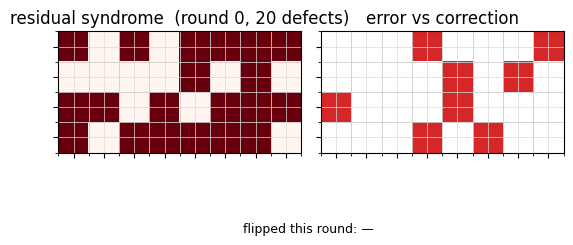

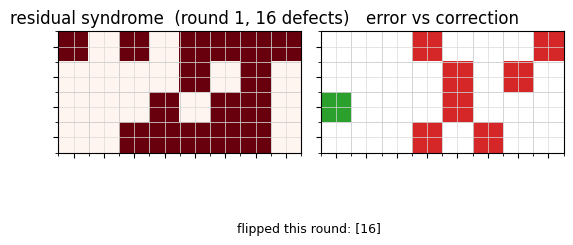

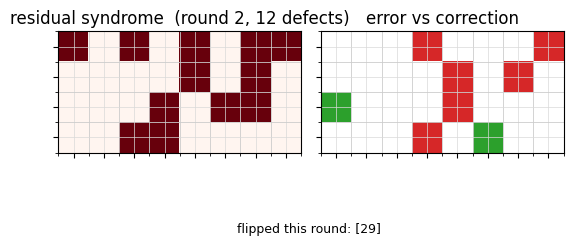

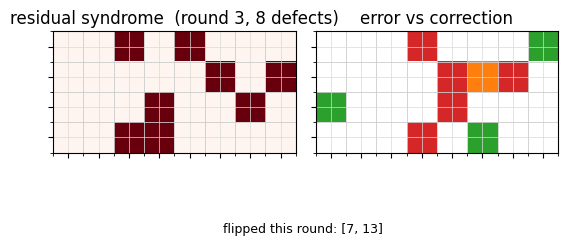

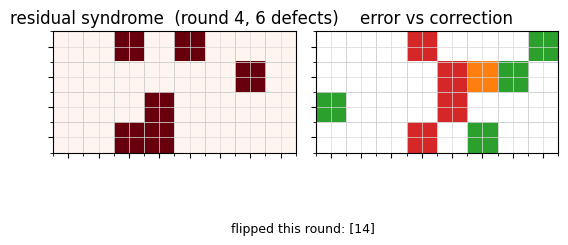

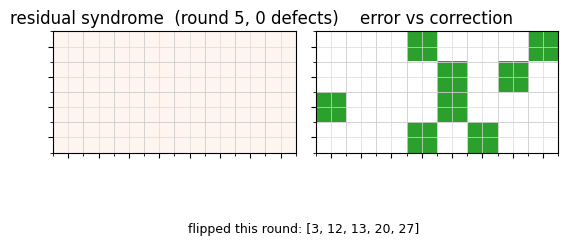

In [18]:
for snap in snaps:
    plot_frame(snap, qubits, L, H)


## 12. Interactive round-stepper (ipywidgets)

Drag the slider to scrub through the decoding rounds. (If `ipywidgets` is not
installed, the ASCII fallback below prints all frames.)

In [19]:
try:
    from ipywidgets import interact, IntSlider
    interact(lambda r: plot_frame(snaps[r], qubits, L, H),
             r=IntSlider(value=0, min=0, max=len(snaps)-1, step=1, description="round idx"))
except Exception as e:
    print("ipywidgets unavailable (%s) -- ASCII frames:\\n" % e)
    for snap in snaps:
        print_frame_ascii(snap, qubits, L, H)


interactive(children=(IntSlider(value=0, description='round idx', max=5), Output()), _dom_classes=('widget-int…

## 13. Interactive experiment — your own error & physical rate

Edit `my_error` (qubit indices) and `p`, re-run, and inspect the decode. Try an
error that *clears the syndrome but fails* (`success=0`) to see leftover orange
`P` / red `X` cells at the end — a logical/stabilizer-inequivalent recovery.

  round 1: defects 8 -> 0
Result: SUCCESS


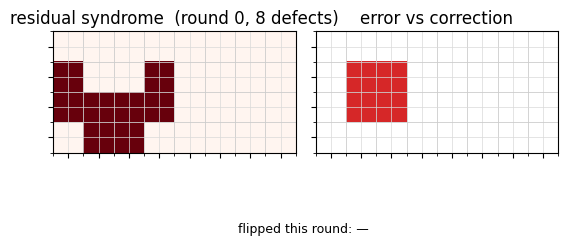

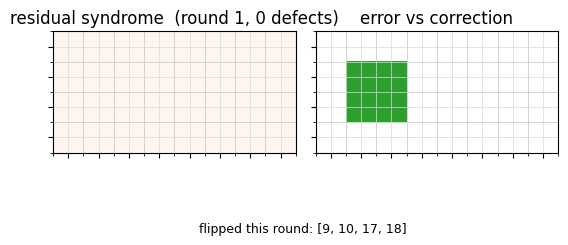

In [20]:
my_error = [9, 10, 17, 18]   # <-- edit me (qubit indices on the L=8,H=4 torus)
my_p = 0.08

W2 = build_edge_weight_matrix(symmetry, L, H, my_p)
q2 = [0]*(L*H)
for idx in my_error: q2[idx] = 1
snaps2 = []
s2, r2 = test_code(my_p, L, H, 0, symmetry, W2,
                   preset_error=my_error, snapshots=snaps2, verbose=True)
print("Result:", {1:"SUCCESS",0:"FAILURE (cleared but wrong)",2:"GAVE UP"}[s2])
plot_frame(snaps2[0], q2, L, H)     # initial
plot_frame(snaps2[-1], q2, L, H)    # final


## 14. Monte-Carlo logical-failure estimate

Sweep `p` and estimate the exact-recovery rate. (Raise `samples` for smoother
curves; this is the Python analogue of `ComputeFailureNumber`.)

p=0.02  exact=150  wrong=  0  gaveup=  0
p=0.04  exact=149  wrong=  0  gaveup=  1
p=0.06  exact=145  wrong=  1  gaveup=  4
p=0.08  exact=141  wrong=  1  gaveup=  8
p=0.10  exact=136  wrong=  4  gaveup= 10
p=0.12  exact=126  wrong=  9  gaveup= 15


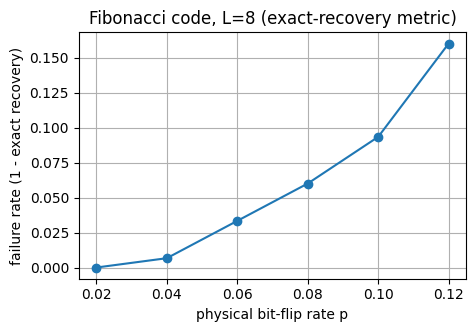

In [21]:
samples = 150
ps = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12]
succ_rate = []
for p in ps:
    Wp = build_edge_weight_matrix(symmetry, L, H, p)
    random.seed(0)
    stats = compute_failure_number(p, L, H, 0, samples, symmetry, Wp)
    succ_rate.append(stats["success"] / stats["samples"])
    print("p=%.2f  exact=%3d  wrong=%3d  gaveup=%3d"
          % (p, stats["success"], stats["incorrect"], stats["give_up"]))

plt.figure(figsize=(5, 3.2))
plt.plot(ps, [1 - s for s in succ_rate], "o-")
plt.xlabel("physical bit-flip rate p"); plt.ylabel("failure rate (1 - exact recovery)")
plt.title("Fibonacci code, L=8 (exact-recovery metric)"); plt.grid(True); plt.show()


---
### Notes & next steps
- Switch `WEIGHT_MODE = "distance"` (cell 0) and re-run for the provably
  repo-faithful `d`-only weighting; compare failure curves.
- The success metric is **exact recovery**, stricter than homological
  equivalence — a return-to-codespace via a stabilizer/logical operator counts
  as failure here, mirroring the C++.
- For larger `L ∈ {16,32,64}` everything scales (matching uses networkx); the
  per-round symmetry sweep is `O(L·H)` matchings, so runtime grows quickly in
  pure Python.